In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
df = pd.DataFrame(pd.read_csv('/home/zeus/programming/python/data/amazon_delivery.csv'))

In [3]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [4]:
df.columns

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='str')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [7]:
df[df['Agent_Rating'].isnull()]

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
124,uurs547552548,23,NaN,22.569358,88.433452,22.599358,88.463452,2022-02-17,23:25:00,23:35:00,Sunny,Low,motorcycle,Metropolitian,75,Snacks
1996,xoaj834389107,32,NaN,0.000000,0.000000,0.050000,0.050000,2022-02-11,20:50:00,21:00:00,Sandstorms,Jam,motorcycle,Urban,185,Snacks
2002,lasr795083832,23,NaN,25.454648,81.834502,25.584648,81.964502,2022-02-18,19:50:00,19:55:00,Windy,Jam,motorcycle,Metropolitian,150,Outdoors
2018,gjcr517387117,26,NaN,0.000000,0.000000,0.080000,0.080000,2022-02-16,23:50:00,23:55:00,Cloudy,Low,scooter,Metropolitian,140,Clothing
3253,ohgx024912559,32,NaN,19.874733,75.353942,19.984733,75.463942,2022-02-16,18:35:00,18:50:00,Sandstorms,Medium,motorcycle,Metropolitian,170,Kitchen
3385,tvng587700125,25,NaN,15.513150,73.783460,15.593150,73.863460,2022-02-18,17:40:00,17:55:00,Sunny,Medium,motorcycle,Urban,115,Clothing
4805,fctw514165232,37,NaN,0.000000,0.000000,0.060000,0.060000,2022-02-15,20:55:00,21:10:00,Cloudy,Jam,motorcycle,Metropolitian,125,Kitchen
6576,yseg007856175,21,NaN,23.264015,77.408236,23.334015,77.478236,2022-02-14,23:35:00,23:50:00,Cloudy,Low,scooter,Metropolitian,120,Kitchen
6580,rpgm542793380,24,NaN,30.372202,78.077151,30.452202,78.157151,2022-02-12,17:40:00,17:45:00,Windy,Medium,van,Metropolitian,110,Pet Supplies
7535,ilse030322540,22,NaN,15.576683,73.755750,15.586683,73.765750,2022-02-11,10:15:00,10:25:00,Stormy,Low,motorcycle,Urban,115,Sports


In [8]:
import plotly.express as px
fig = px.scatter_mapbox(df, lat="Drop_Latitude", lon="Drop_Longitude", zoom=3)
fig.update_layout(mapbox_style="open-street-map")
fig.show()


/tmp/ipykernel_30496/2023371954.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(df, lat="Drop_Latitude", lon="Drop_Longitude", zoom=3)


In [9]:
df = df.dropna(subset=['Weather'])

In [10]:
df.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather             0
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [11]:
mean = df['Agent_Rating'].mean()
mean = np.floor(mean)

In [12]:
conditions = [
    df['Agent_Rating'].isnull()
]
choices = [
    mean
]

df['Agent_Rating'] = np.select(conditions, choices, default=df['Agent_Rating'])


In [13]:
df.columns

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='str')

In [14]:
df['Order_Time']

0        11:30:00
1        19:45:00
2        08:30:00
3        18:00:00
4        13:30:00
           ...   
43734    11:35:00
43735    19:55:00
43736    23:50:00
43737    13:35:00
43738    17:10:00
Name: Order_Time, Length: 43648, dtype: str

In [15]:
df['Order_Time'] = pd.to_datetime(df['Order_Time'])

/tmp/ipykernel_30496/1299114674.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Time'] = pd.to_datetime(df['Order_Time'])


In [16]:
df['Order_Time']

0       2026-06-24 11:30:00
1       2026-06-24 19:45:00
2       2026-06-24 08:30:00
3       2026-06-24 18:00:00
4       2026-06-24 13:30:00
                ...        
43734   2026-06-24 11:35:00
43735   2026-06-24 19:55:00
43736   2026-06-24 23:50:00
43737   2026-06-24 13:35:00
43738   2026-06-24 17:10:00
Name: Order_Time, Length: 43648, dtype: datetime64[us]

In [17]:
df['Hour_of_Day'] = df['Order_Time'].dt.hour

In [18]:
df['Hour_of_Day']

0        11
1        19
2         8
3        18
4        13
         ..
43734    11
43735    19
43736    23
43737    13
43738    17
Name: Hour_of_Day, Length: 43648, dtype: int32

In [19]:
hours = df['Hour_of_Day'].unique()

In [20]:
dc = {}
for i in range(0,24):
    dc[i] = 0 
for i in df['Hour_of_Day']:
    if i in dc.keys():
        dc[i] += 1

In [21]:
dc

{0: 429,
 1: 0,
 2: 0,
 3: 0,
 4: 0,
 5: 0,
 6: 0,
 7: 0,
 8: 1810,
 9: 1934,
 10: 1980,
 11: 1950,
 12: 888,
 13: 779,
 14: 785,
 15: 871,
 16: 706,
 17: 4247,
 18: 4467,
 19: 4579,
 20: 4504,
 21: 4663,
 22: 4558,
 23: 4498}

# No. Of Orders Per Hour

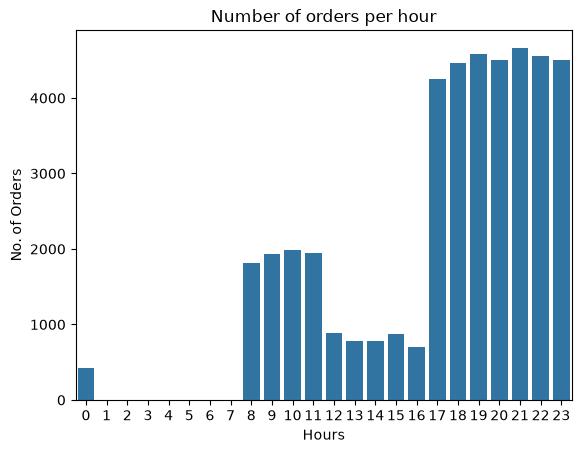

In [22]:
ax = sns.barplot(data=dc, x=dc.keys(), y=dc.values())

ax.set(title="Number of orders per hour", xlabel="Hours", ylabel="No. of Orders")

plt.show()


In [23]:
df['Agent_Rating'].unique()
df['Category'].unique()

<StringArray>
[    'Clothing',  'Electronics',       'Sports',    'Cosmetics',
         'Toys',       'Snacks',        'Shoes',      'Apparel',
      'Jewelry',     'Outdoors',      'Grocery',        'Books',
      'Kitchen',         'Home', 'Pet Supplies',     'Skincare']
Length: 16, dtype: str

In [24]:
# dc = {}
# for i in range(0,24):
#     dc[i] = [] 
# for i in df['Order_ID']:
#     hour = df.loc[df['Order_ID'] == i, ['Hour_of_Day']]
#     rating = df.loc[df['Hour_of_Day'] == hour['Hour_of_Day'].item(), ['Agent_Rating']]
#     dc[hour['Hour_of_Day'].item()].append(rating)
# dc


In [ ]:
df['RoundDropLat'] = df['Drop_Latitude'].round(decimals=1)
df['RoundDropLong'] = df['Drop_Longitude'].round(decimals=1)
df

In [26]:
latls = []
for i in df['RoundDropLat']:
    latls.append(int(i*10))
longls = []
for i in df['RoundDropLong']:
    longls.append(int(i*10))



In [ ]:
import reverse_geocoder as rg

# Group coordinates into city-like bins using math (rounding to 0.1 degrees)
city_counts = {}
for row in df.itertuples():
    lat_bin = int(row.Drop_Latitude * 10) / 10
    lon_bin = int(row.Drop_Longitude * 10) / 10
    coord_key = (lat_bin, lon_bin)
    city_counts[coord_key] = city_counts.get(coord_key, 0) + 1

# Optionally resolve one representative city name per bin
city_names = {}
for coord_key in city_counts:
    results = rg.search(coord_key)
    city_names[coord_key] = results[0]['name']

city_counts, city_names




In [ ]:
city_df = pd.DataFrame([
    {
        "city": f"{city_names[key]}",
        "count": count,
    }
    for key, count in city_counts.items()
])


city_df['city'].duplicated().sum()
city_df = city_df.groupby('city', as_index=False).sum()
city_df.duplicated().sum()

np.int64(0)

/tmp/ipykernel_30496/1242854532.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities, x="city", y="count", palette="viridis")


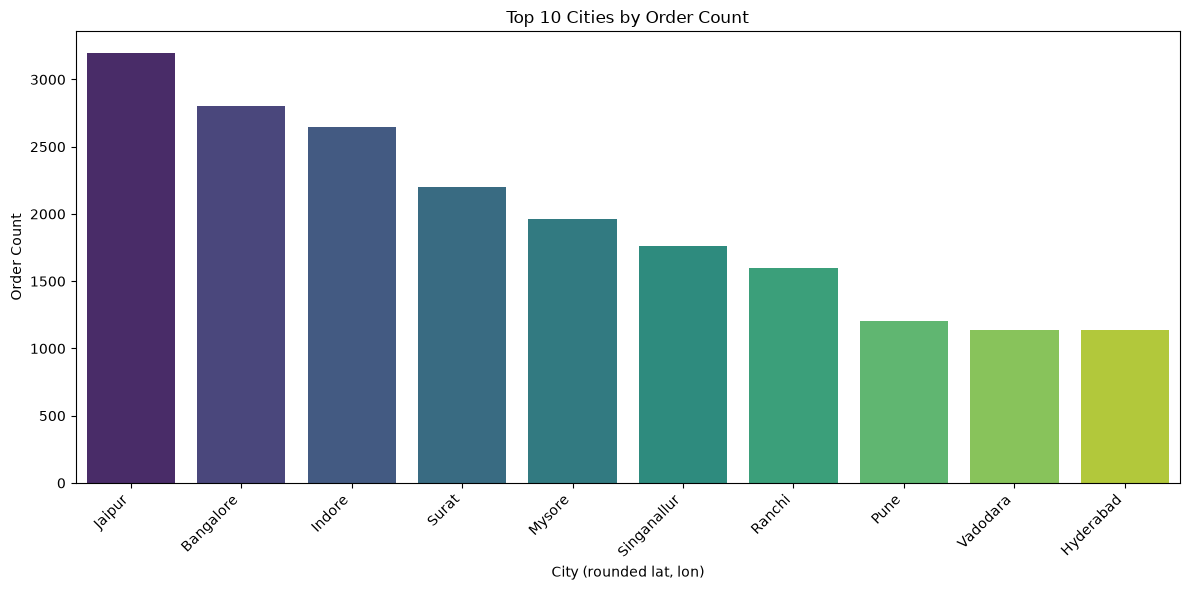

,city,count
0,Jaipur,3198
1,Bangalore,2800
2,Indore,2645
3,Surat,2201
4,Mysore,1960
5,Singanallur,1759
6,Ranchi,1601
7,Pune,1203
8,Vadodara,1137
9,Hyderabad,1135


In [48]:
city_df = city_df.sort_values("count", ascending=False).reset_index(drop=True)
top_cities = city_df.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cities, x="city", y="count", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Cities by Order Count")
plt.xlabel("City (rounded lat, lon)")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

top_cities

In [70]:
meanDeliveryTime = df['Delivery_Time'].mean()
round(meanDeliveryTime)

125

In [71]:
weather = df['Weather'].unique()
dc = {}
for w in weather:
    mean = df.loc[df['Weather'] == w, 'Delivery_Time'].mean()
    mean = round(mean)
    dc[w] = mean
dc  

{'Sunny': 104,
 'Stormy': 123,
 'Sandstorms': 123,
 'Cloudy': 138,
 'Fog': 137,
 'Windy': 124}

,weather,average_delivery_time
0,Sunny,104
1,Stormy,123
2,Sandstorms,123
3,Cloudy,138
4,Fog,137
5,Windy,124


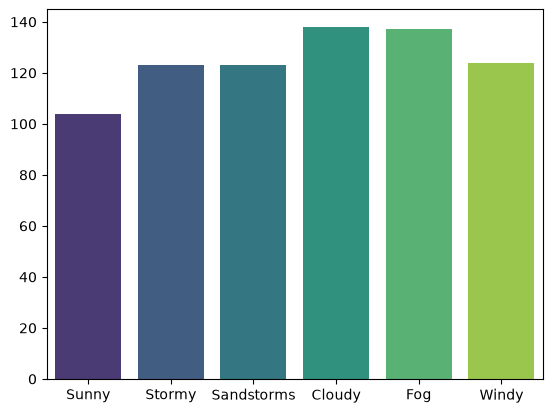

In [83]:
sns.barplot(data=dc, x=dc.keys(),y=dc.values(), hue=dc.keys(), palette='viridis')
pd.DataFrame(dc.items(), columns=['weather', 'average_delivery_time'])

In [79]:
averageAgentAge = df['Agent_Age'].mean()
round(averageAgentAge,1)

np.float64(29.6)

In [96]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['OrderMonth'] = df['Order_Date'].dt.month

df['OrderMonth'].value_counts()
df['Order_Date']

0       2022-03-19
1       2022-03-25
2       2022-03-19
3       2022-04-05
4       2022-03-26
           ...    
43734   2022-03-24
43735   2022-02-16
43736   2022-03-11
43737   2022-03-07
43738   2022-03-02
Name: Order_Date, Length: 43648, dtype: datetime64[us]

In [108]:
df[df['Order_Date'] == pd.Timestamp('2022-02-14')].value_counts().sum()


np.int64(823)

In [137]:
dates = df['Order_Date'].unique()

In [160]:
dateData = {}
for d in dates:
    sum = df[df['Order_Date'] == pd.Timestamp(d)].value_counts().sum()
    dateData[d] = sum 

dateData

{Timestamp('2022-03-19 00:00:00'): np.int64(1100),
 Timestamp('2022-03-25 00:00:00'): np.int64(930),
 Timestamp('2022-04-05 00:00:00'): np.int64(1106),
 Timestamp('2022-03-26 00:00:00'): np.int64(1119),
 Timestamp('2022-03-11 00:00:00'): np.int64(1090),
 Timestamp('2022-03-04 00:00:00'): np.int64(944),
 Timestamp('2022-03-14 00:00:00'): np.int64(930),
 Timestamp('2022-03-20 00:00:00'): np.int64(941),
 Timestamp('2022-02-12 00:00:00'): np.int64(836),
 Timestamp('2022-02-13 00:00:00'): np.int64(921),
 Timestamp('2022-02-14 00:00:00'): np.int64(823),
 Timestamp('2022-04-02 00:00:00'): np.int64(942),
 Timestamp('2022-03-01 00:00:00'): np.int64(1071),
 Timestamp('2022-03-16 00:00:00'): np.int64(952),
 Timestamp('2022-02-15 00:00:00'): np.int64(903),
 Timestamp('2022-03-10 00:00:00'): np.int64(947),
 Timestamp('2022-03-27 00:00:00'): np.int64(929),
 Timestamp('2022-03-12 00:00:00'): np.int64(927),
 Timestamp('2022-04-01 00:00:00'): np.int64(1092),
 Timestamp('2022-03-05 00:00:00'): np.int64(

In [161]:
dateData = pd.DataFrame(dateData.items(), columns=['dates', 'orders'])
dateData

,dates,orders
0,2022-03-19,1100
1,2022-03-25,930
2,2022-04-05,1106
3,2022-03-26,1119
4,2022-03-11,1090
5,2022-03-04,944
6,2022-03-14,930
7,2022-03-20,941
8,2022-02-12,836
9,2022-02-13,921


In [165]:
sort = dateData.sort_values(by='orders')
sort
sort.tail(5)

,dates,orders
37,2022-03-03,1116
3,2022-03-26,1119
30,2022-03-13,1120
22,2022-04-03,1131
35,2022-03-15,1139
